# Validation-curve comparison

Interactive version of `scripts/plot_val_curves.py`.

Each entry of the YAML config points at a training-run directory.  For every run
we

1. load the run's own `.hydra/config.yaml` to recover the loss weights
   (`finetune.loss_weights.*`) and the augmentation strength `lambda`,
2. read the per-epoch metric from the Lightning `metrics.csv`,
3. draw the curve, coloured on a blue → red scale, and mark the best (lowest)
   epoch with a star of the same colour.

**Colour scale.** `SCALE = 'uniform'` spreads the colours evenly over the runs
ordered by λ, so consecutive λ values are always equally distinguishable
regardless of how they are spaced.  `SCALE = 'value'` instead maps the colour to
the λ *value* through `color.vmin` / `color.vmax`, which makes the colour
quantitative but crowds together λ values that happen to sit close.  Runs with
jet-contrastive weight 0 are drawn in the baseline colour (black) either way.

In [42]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
from omegaconf import DictConfig, OmegaConf

%matplotlib inline

# Repo root, whether the kernel started in notebooks/ or at the repo root.
REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file()
)

CONFIG_PATH = REPO_ROOT / 'scripts/configs/val_loss_ce_lambda_scan_reduced.yaml'
SCALE = 'uniform'  # 'uniform' (evenly spaced by rank) | 'value' (proportional to lambda)

## Run resolution: hydra config + metrics.csv

In [43]:
def find_run_config(run_dir: Path) -> DictConfig:
    """Load the newest ``.hydra/config.yaml`` under ``run_dir`` (one per rank)."""
    candidates = sorted(
        run_dir.glob('outputs/*/*/.hydra/config.yaml'),
        key=lambda p: p.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(f'No .hydra/config.yaml found under {run_dir}')
    return OmegaConf.load(candidates[-1])


def find_metrics(run_dir: Path) -> Path:
    """Locate the newest Lightning ``metrics.csv`` under ``run_dir``."""
    candidates = sorted(
        run_dir.glob('*/version_*/metrics.csv'), key=lambda p: p.stat().st_mtime
    )
    if not candidates:
        raise FileNotFoundError(f'No */version_*/metrics.csv found under {run_dir}')
    return candidates[-1]


def read_metric(metrics_csv: Path, metric: str) -> pd.DataFrame:
    """Return the per-epoch ``metric`` series as columns ``epoch`` / ``value``.

    Rows without the metric (train-step rows) are dropped; epochs logged more
    than once are averaged.
    """
    df = pd.read_csv(metrics_csv)
    if metric not in df.columns:
        raise KeyError(
            f'{metrics_csv} has no column {metric!r} (has {list(df.columns)})'
        )

    series = df[df[metric].notna()][['epoch', metric]]
    series = series.groupby('epoch', as_index=False)[metric].mean()
    series = series.rename(columns={metric: 'value'}).sort_values('epoch')
    series['epoch'] = series['epoch'].astype(int)
    return series.reset_index(drop=True)

## Model entries

In [44]:
@dataclass
class Run:
    """One training run: its curve plus the hyper-parameters that label it."""

    label: str | None
    lam: float
    jc: float
    ce: float
    curve: pd.DataFrame
    color: str | None = None

    @property
    def best_epoch(self) -> int:
        return int(self.curve.loc[self.curve['value'].idxmin(), 'epoch'])

    @property
    def best_value(self) -> float:
        return float(self.curve['value'].min())


def load_run(entry: DictConfig, metric: str) -> Run:
    """Build a ``Run`` from a config entry, reading what it does not override."""
    run_dir = Path(entry['dir'])
    if not run_dir.is_dir():
        raise FileNotFoundError(f'Run directory {run_dir} not found')

    run_cfg = find_run_config(run_dir)
    weights = OmegaConf.select(run_cfg, 'finetune.loss_weights') or {}

    return Run(
        label=entry.get('label'),
        lam=float(entry.get('lam', OmegaConf.select(run_cfg, 'lambda'))),
        jc=float(entry.get('jc', weights.get('jet_contrastive', 0.0))),
        ce=float(entry.get('ce', weights.get('cross_entropy', 0.0))),
        curve=read_metric(find_metrics(run_dir), metric),
        color=entry.get('color'),
    )


def auto_label(run: Run, uniform_jc: bool) -> str:
    """Legend label: only the fields that actually vary across the comparison."""
    if run.label is not None:
        return run.label
    if run.jc == 0.0:
        #return f'no JC  ($\\lambda$ = {run.lam:g})'
        return f'no Contr.'
    if uniform_jc:
        return f'$\\lambda$ = {run.lam:g}'
    return f'JC {run.jc:g},  $\\lambda$ = {run.lam:g}'

## Load the runs

In [45]:
cfg = OmegaConf.load(CONFIG_PATH)
metric = cfg.get('metric', 'val/head/loss_ce')

runs = [load_run(entry, metric) for entry in cfg['models']]

summary = pd.DataFrame(
    [
        {
            'ce': r.ce,
            'jc': r.jc,
            'lambda': r.lam,
            'epochs': len(r.curve),
            'best': r.best_value,
            'best_epoch': r.best_epoch,
        }
        for r in sorted(runs, key=lambda r: (r.jc != 0.0, r.lam))
    ]
)
summary

,ce,jc,lambda,epochs,best,best_epoch
0,1.0,0.0,0.03,25,0.604803,9
1,1.0,1.0,0.03,22,0.608586,6
2,1.0,1.0,0.10,27,0.607278,11
3,1.0,1.0,0.15,27,0.606110,9
4,1.0,1.0,0.20,33,0.604505,11
5,1.0,1.0,0.25,35,0.603322,17
6,1.0,1.0,0.30,50,0.602553,22
7,1.0,1.0,0.35,50,0.604813,29
8,1.0,1.0,0.40,50,0.603634,49
9,1.0,1.0,0.45,29,0.609048,28


## Colours and plot

In [46]:
def assign_colors(
    runs: list[Run], cmap, scale: str, norm: Normalize, baseline_color: str
) -> list:
    """One colour per run, in the order given.

    ``scale='uniform'`` spaces the scan runs evenly over the colormap by their
    rank in lambda; ``scale='value'`` maps the lambda value through ``norm``.
    Runs with ``jc == 0`` get ``baseline_color``, and an explicit ``color:`` in
    the config always wins.
    """
    scan = [r for r in runs if r.jc != 0.0]
    rank = {id(r): k for k, r in enumerate(sorted(scan, key=lambda r: r.lam))}
    span = max(len(scan) - 1, 1)

    colors = []
    for run in runs:
        if run.color is not None:
            colors.append(run.color)
        elif run.jc == 0.0:
            colors.append(baseline_color)
        elif scale == 'uniform':
            colors.append(cmap(rank[id(run)] / span))
        else:
            colors.append(cmap(norm(run.lam)))
    return colors


def plot_curves(runs: list[Run], cfg: DictConfig, scale: str = SCALE):
    """Draw all curves on one axes and return ``(fig, ax)``."""
    style = cfg.get('color', {})
    cmap = LinearSegmentedColormap.from_list(
        'blue_red', list(style.get('cmap', ['#1f3ecc', '#7a1fa2', '#cc1f1f']))
    )
    norm = Normalize(
        vmin=float(style.get('vmin', 0.0)), vmax=float(style.get('vmax', 1.0))
    )

    # Baselines first, then the scan in ascending lambda, so the legend reads as
    # a gradient.
    runs = sorted(runs, key=lambda r: (r.jc != 0.0, r.lam))
    colors = assign_colors(
        runs, cmap, scale, norm, style.get('baseline_color', 'black')
    )
    uniform_jc = len({r.jc for r in runs if r.jc != 0.0}) <= 1

    plot_cfg = cfg.get('plot', {})
    fig, ax = plt.subplots(figsize=tuple(plot_cfg.get('figsize', [8.0, 5.0])))

    for run, color in zip(runs, colors):
        ax.plot(
            run.curve['epoch'],
            run.curve['value'],
            color=color,
            linewidth=1.4,
            label=auto_label(run, uniform_jc),
        )
        ax.plot(
            run.best_epoch,
            run.best_value,
            marker='*',
            markersize=12,
            color=color,
            markeredgecolor='white',
            markeredgewidth=0.5,
            linestyle='none',
            zorder=5,
        )

    ax.set_xlabel(plot_cfg.get('xlabel', 'Epoch'))
    ax.set_ylabel(plot_cfg.get('ylabel', cfg['metric']))
    if plot_cfg.get('title'):
        ax.set_title(plot_cfg['title'])
    if plot_cfg.get('ylim'):
        ax.set_ylim(*plot_cfg['ylim'])
    if plot_cfg.get('xlim'):
        ax.set_xlim(*plot_cfg['xlim'])
    ax.grid(True, alpha=0.3)

    legend_kwargs = {'fontsize': 8, 'title': plot_cfg.get('legend_title')}
    if plot_cfg.get('legend_outside', True):
        legend_kwargs |= {'loc': 'upper left', 'bbox_to_anchor': (1.01, 1.0)}
    else:
        legend_kwargs |= {'loc': 'best', 'ncol': 2}
    ax.legend(**legend_kwargs)

    # A colourbar only carries meaning when the colour tracks the lambda value.
    if style.get('colorbar', False) and scale == 'value':
        bar = fig.colorbar(
            plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.02
        )
        bar.set_label('$\\lambda$')



    fig.tight_layout()
    return fig, ax

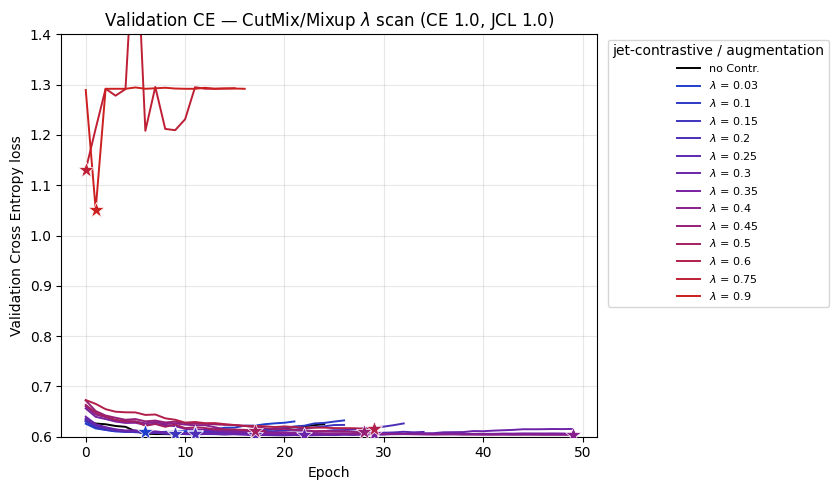

In [47]:
fig, ax = plot_curves(runs, cfg)

## Tweak and save

Re-run the cell above after editing anything — `ax` is live, so you can also
adjust it in place (`ax.set_ylim(...)`, `ax.set_title(...)`) and redisplay
`fig`.  Set `SCALE = 'value'` in the setup cell to colour by the λ value
instead of by rank.

In [48]:
out_dir = REPO_ROOT / cfg.get('plot', {}).get('out_dir', 'plots/val_curves')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / cfg.get('plot', {}).get('filename', 'val_curves.png')

fig.savefig(out_path, dpi=200, bbox_inches='tight')
print(f'Saved {out_path}')

Saved /storage3/DSIP/rriva/research/fm4tag/plots/val_loss_ce/val_loss_ce_lambda_scan_5.png
